# P1 - Problema, dataset y EDA

Proyecto final de Machine Learning

Este notebook cubre la etapa 1 del proyecto de acuerdo con la guía del curso. Se presenta la formulación del problema, la descripción del dataset y el análisis exploratorio de datos (EDA) para el caso de uso de churn de clientes de telecomunicaciones.

Dataset utilizado:
- `WA_Fn-UseC_-Telco-Customer-Churn.csv`


## 1. Descripción y motivación del problema

Las empresas de telecomunicaciones operan en mercados altamente competitivos y la retención de clientes es una prioridad estratégica. El churn (abandono del servicio) afecta directamente los ingresos, aumenta los costos de adquisición y refleja la insatisfacción o la falta de valor percibido por parte del cliente.

En este contexto, el objetivo del proyecto es comprender qué factores están asociados con la salida de clientes y preparar el terreno para un modelo predictivo que permita identificar clientes con alto riesgo de churn.

### Tarea de Machine Learning
Se trata de un problema de clasificación binaria: predecir si un cliente abandonará el servicio (`Churn = Yes`) o no (`Churn = No`) en función de variables de comportamiento, contrato, servicios contratados y perfil del cliente.

### Preguntas de investigación
1. ¿Qué características están más asociadas con la deserción?
2. ¿Existe una relación clara entre el tipo de contrato, la duración del servicio y la tasa de churn?
3. ¿Los clientes con servicios adicionales o contratos más largos presentan menor propensión a abandonar?
4. ¿Hay señales de sesgo, datos faltantes o problemas de calidad que deban tratarse antes de entrenar modelos?


In [32]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

from pathlib import Path

root = Path('..')
file_path = root / 'data' /'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)
print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
df.head()


Filas: 7,043
Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Descripción del dataset

El conjunto de datos contiene información de clientes de telecomunicaciones y una variable objetivo binaria `Churn`, que indica si el cliente se retiró del servicio. El dataset incluye 7,043 clientes y 21 columnas.

### Variable objetivo
- `Churn`: `Yes` si el cliente abandonó, `No` si no lo hizo.

### Tipos de variables
- Variables demográficas: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- Variables de servicio: `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
- Variables de cuenta y facturación: `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`
- Identificador: `customerID`


In [33]:
print(df.info())
print(f'\nDuplicados: {df.duplicated().sum()}')
print(f'Valores faltantes totales: {df.isna().sum().sum()}')
print('\nTipos de columnas:')
print(df.dtypes)


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Revisión inicial de calidad de datos

Durante la inspección de tipos encontramos dos aspectos relevantes:

1. `TotalCharges` se interpreta como texto en lugar de numérico, lo que requiere limpieza antes de análisis.
2. `SeniorCitizen` ya tiene codificación binaria (0/1), mientras el resto de variables binarias están representadas como `Yes/No`.

Estos detalles son importantes porque afectan tanto los análisis descriptivos como el preprocesamiento posterior.


In [34]:
# Ajuste de tipos y detección de valores vacíos representados como cadenas
df['TotalCharges'] = df['TotalCharges'].replace(' ', pd.NA)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Valores faltantes por columna:')
print(df.isna().sum().sort_values(ascending=False))

df[['TotalCharges', 'MonthlyCharges', 'tenure']].head()


Valores faltantes por columna:
TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64


,TotalCharges,MonthlyCharges,tenure
0,29.85,29.85,1
1,1889.50,56.95,34
2,108.15,53.85,2
3,1840.75,42.30,45
4,151.65,70.70,2


In [35]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unique': df.nunique(),
    'missing': df.isna().sum(),
    'sample_values': [df[col].dropna().unique()[:5].tolist() for col in df.columns]
})
summary


,dtype,n_unique,missing,sample_values
customerID,str,7043,0,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC..."
gender,str,2,0,"[Female, Male]"
SeniorCitizen,int64,2,0,"[0, 1]"
Partner,str,2,0,"[Yes, No]"
Dependents,str,2,0,"[No, Yes]"
tenure,int64,73,0,"[1, 34, 2, 45, 8]"
PhoneService,str,2,0,"[No, Yes]"
MultipleLines,str,3,0,"[No phone service, No, Yes]"
InternetService,str,3,0,"[DSL, Fiber optic, No]"
OnlineSecurity,str,3,0,"[No, Yes, No internet service]"


## 4. Distribución de la variable objetivo (`Churn`)

La variable objetivo es binaria. Antes de construir modelos, es importante estudiar su balance y verificar si hay desbalance de clases. Esto influye en la elección de métricas, el punto de corte y la validación.


  Churn  count        pct
0    No   5174  73.463013
1   Yes   1869  26.536987


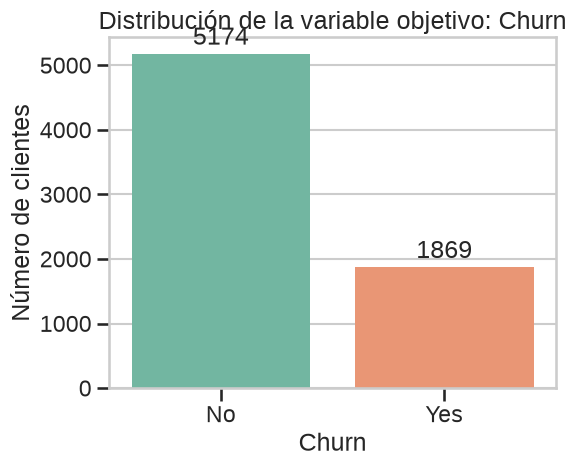

In [36]:
churn_counts = df['Churn'].value_counts(dropna=False).rename_axis('Churn').reset_index(name='count')
churn_counts['pct'] = churn_counts['count'] / churn_counts['count'].sum() * 100
print(churn_counts)

fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(data=df, x='Churn', palette='Set2', ax=ax)
ax.set_title('Distribución de la variable objetivo: Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Número de clientes')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.tight_layout()
plt.show()


## 5. Estadísticas descriptivas de variables numéricas

Se analizan las variables numéricas: `tenure`, `MonthlyCharges` y `TotalCharges`. También se comparan sus distribuciones por la variable objetivo para detectar patrones de churn.


In [37]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
summary_numeric = df[numeric_cols].describe().T
summary_numeric


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


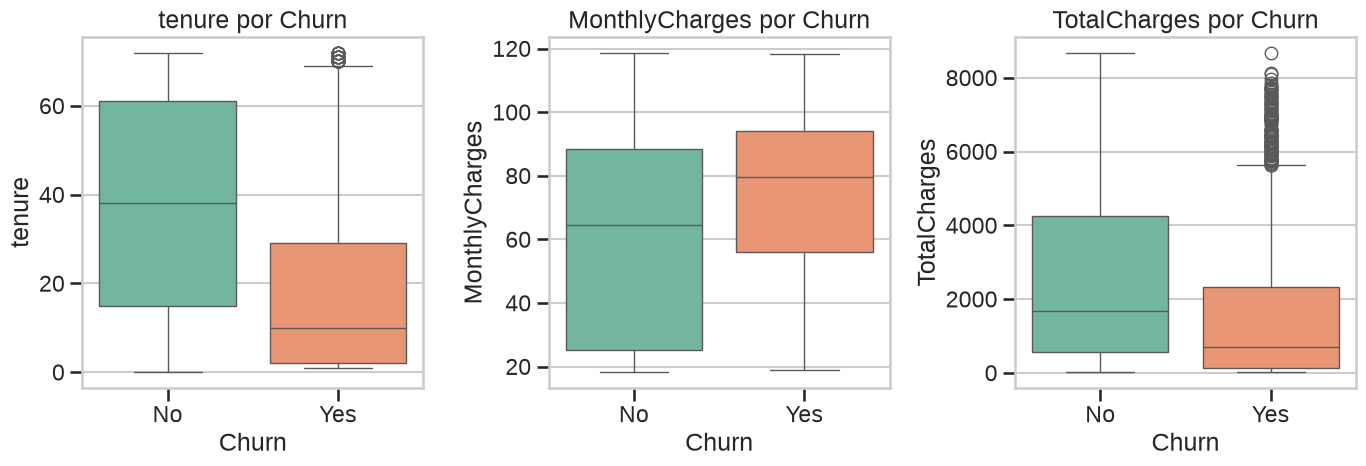

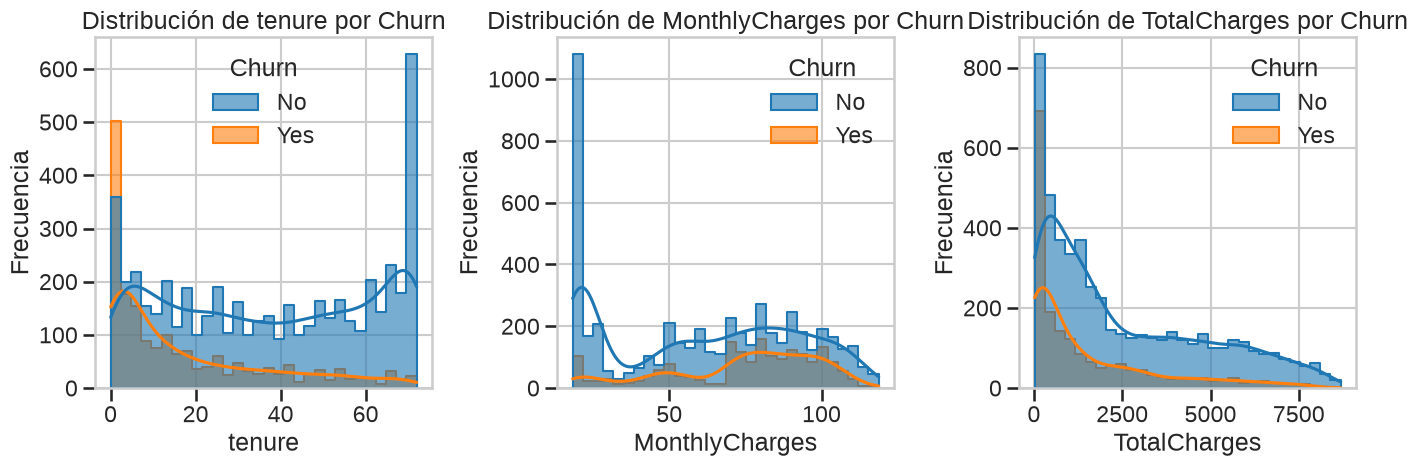

In [38]:
plt.figure(figsize=(14, 5))
for i, col in enumerate(numeric_cols, start=1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x='Churn', y=col, palette='Set2')
    plt.title(f'{col} por Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
for i, col in enumerate(numeric_cols, start=1):
    plt.subplot(1, 3, i)
    sns.histplot(data=df, x=col, hue='Churn', bins=30, kde=True, element='step', alpha=0.6)
    plt.title(f'Distribución de {col} por Churn')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


## 6. Análisis de variables categóricas y relaciones con churn

La mayor parte del dataset es categórico. Es importante estudiar cómo cambia la proporción de churn según cada característica para identificar señales útiles para modelado y para apoyar la hipótesis del problema.


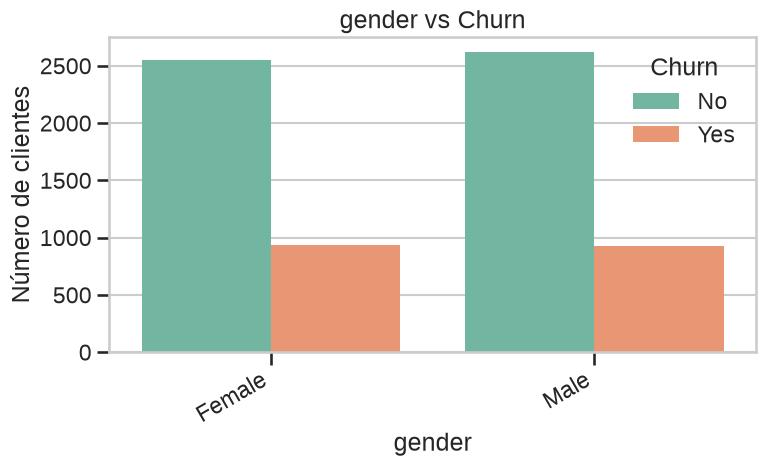


--- gender ---
Churn     No   Yes
gender            
Female  73.1  26.9
Male    73.8  26.2


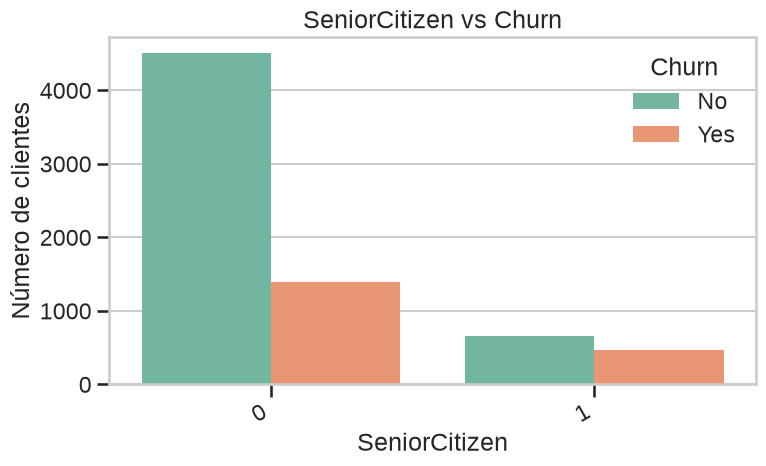


--- SeniorCitizen ---
Churn            No   Yes
SeniorCitizen            
0              76.4  23.6
1              58.3  41.7


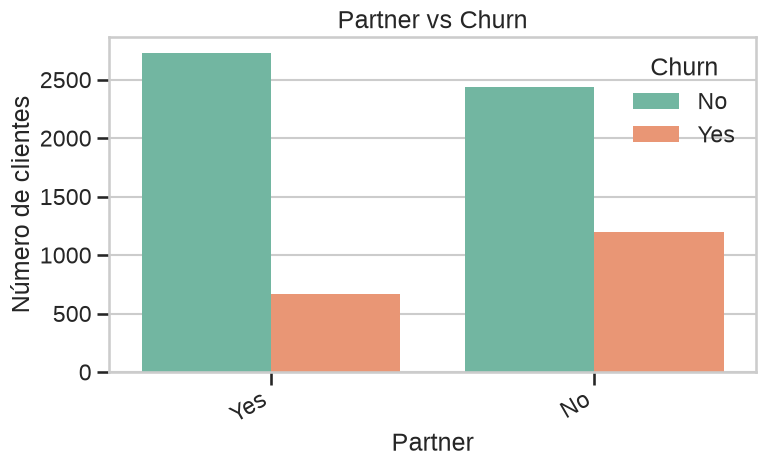


--- Partner ---
Churn      No   Yes
Partner            
No       67.0  33.0
Yes      80.3  19.7


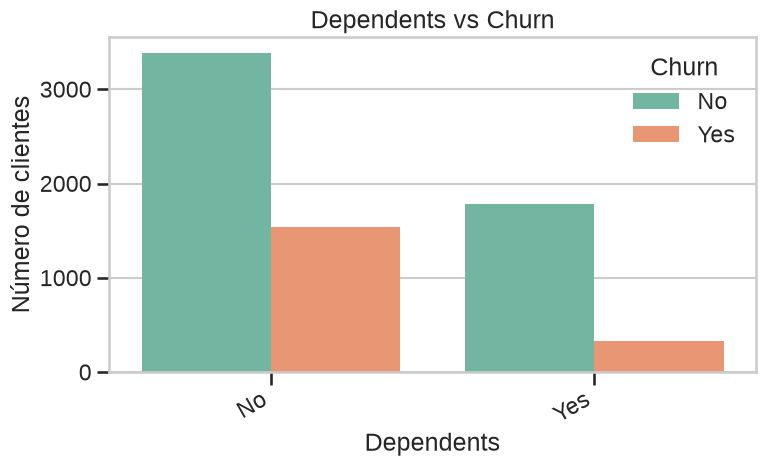


--- Dependents ---
Churn         No   Yes
Dependents            
No          68.7  31.3
Yes         84.5  15.5


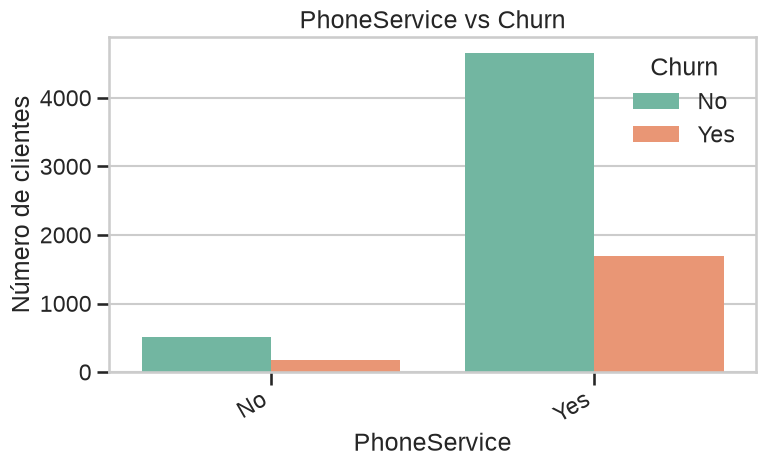


--- PhoneService ---
Churn           No   Yes
PhoneService            
No            75.1  24.9
Yes           73.3  26.7


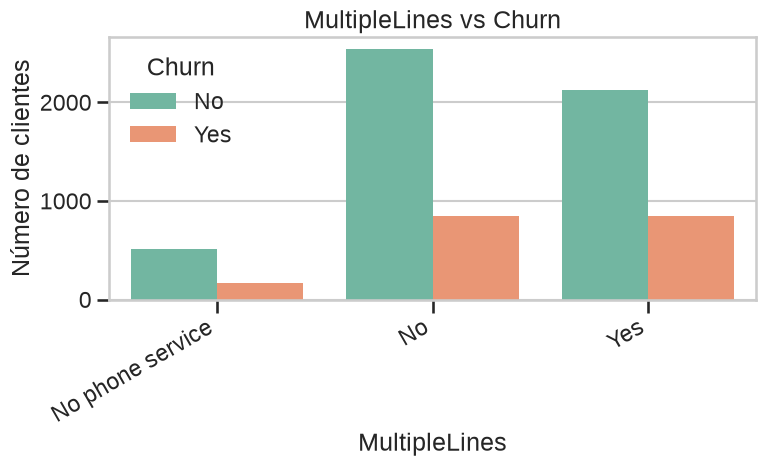


--- MultipleLines ---
Churn               No   Yes
MultipleLines               
No                75.0  25.0
No phone service  75.1  24.9
Yes               71.4  28.6


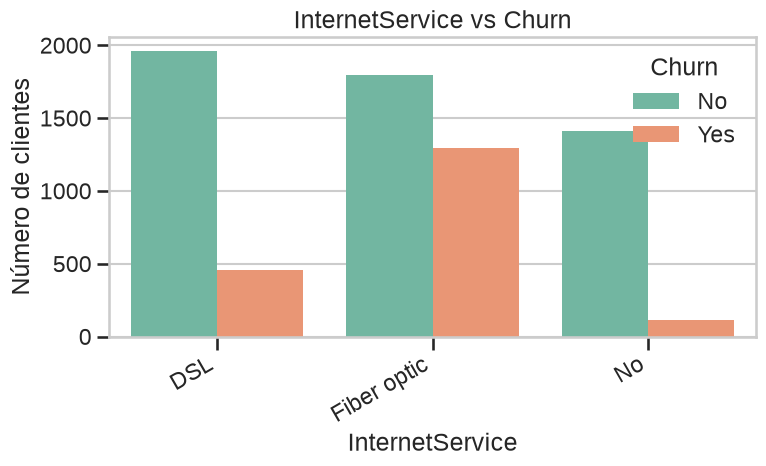


--- InternetService ---
Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4


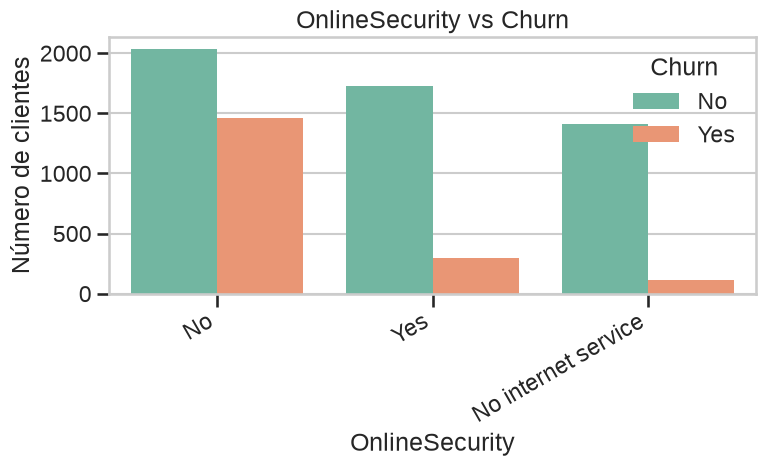


--- OnlineSecurity ---
Churn                  No   Yes
OnlineSecurity                 
No                   58.2  41.8
No internet service  92.6   7.4
Yes                  85.4  14.6


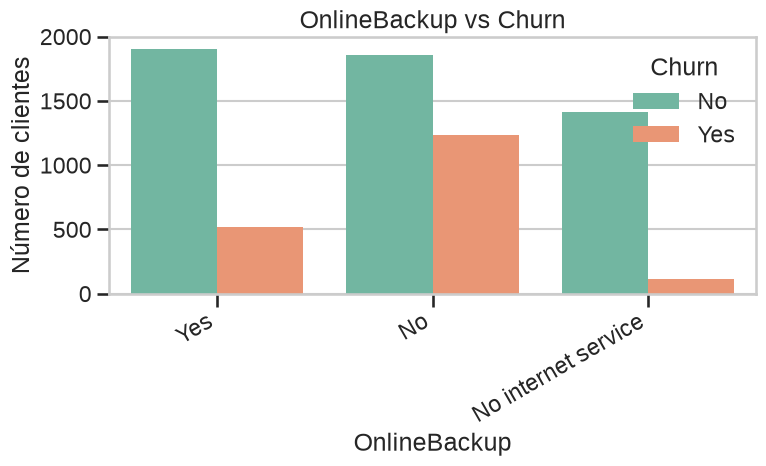


--- OnlineBackup ---
Churn                  No   Yes
OnlineBackup                   
No                   60.1  39.9
No internet service  92.6   7.4
Yes                  78.5  21.5


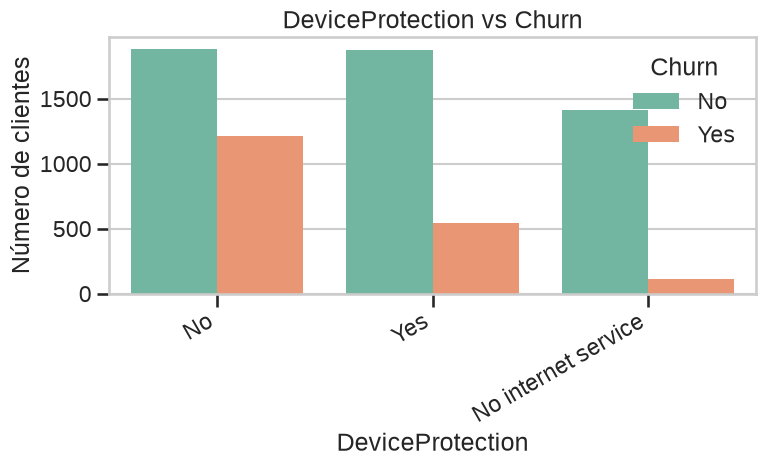


--- DeviceProtection ---
Churn                  No   Yes
DeviceProtection               
No                   60.9  39.1
No internet service  92.6   7.4
Yes                  77.5  22.5


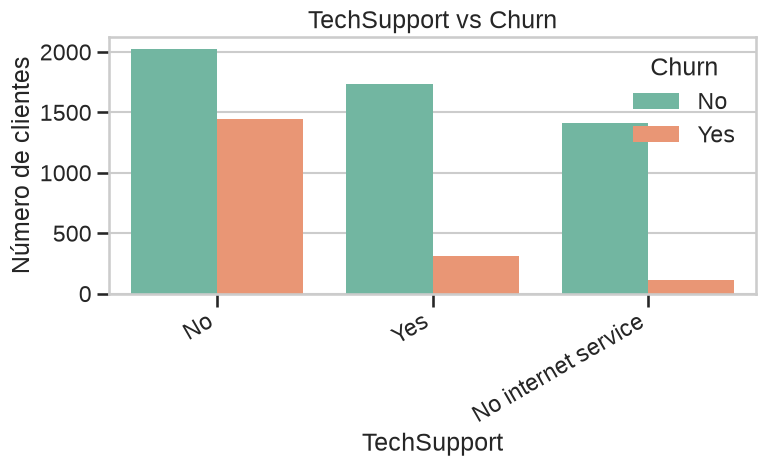


--- TechSupport ---
Churn                  No   Yes
TechSupport                    
No                   58.4  41.6
No internet service  92.6   7.4
Yes                  84.8  15.2


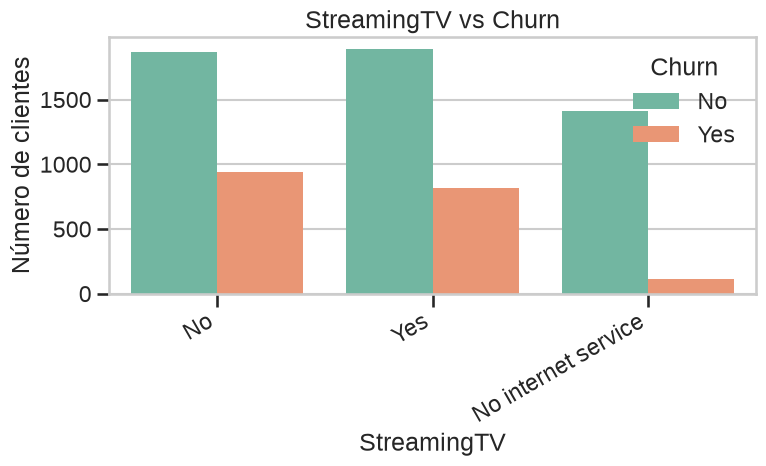


--- StreamingTV ---
Churn                  No   Yes
StreamingTV                    
No                   66.5  33.5
No internet service  92.6   7.4
Yes                  69.9  30.1


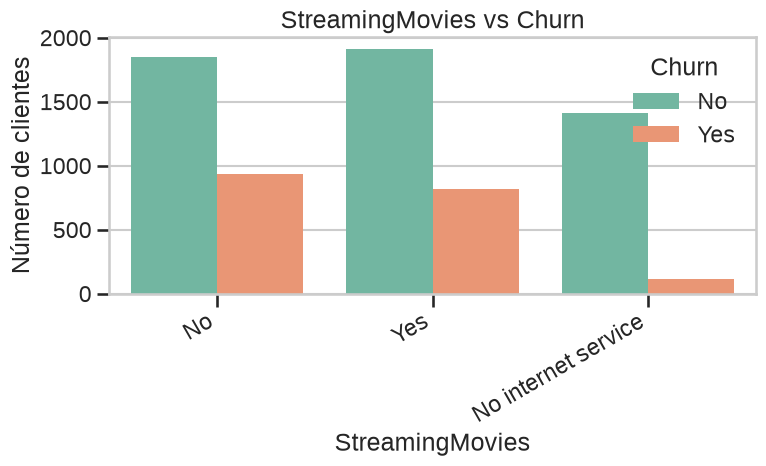


--- StreamingMovies ---
Churn                  No   Yes
StreamingMovies                
No                   66.3  33.7
No internet service  92.6   7.4
Yes                  70.1  29.9


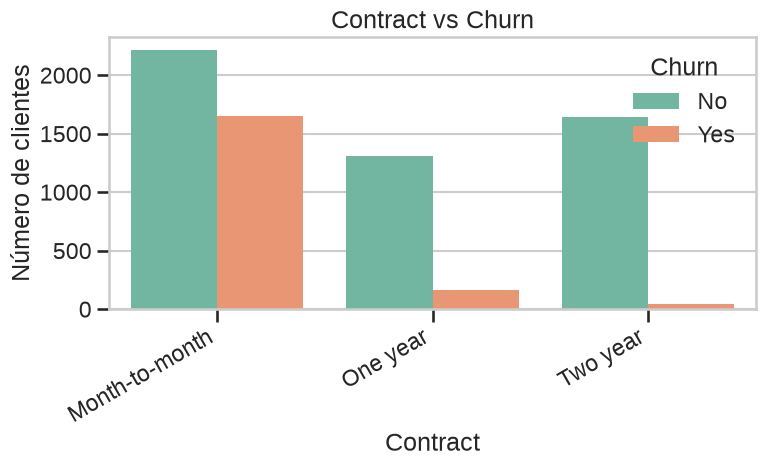


--- Contract ---
Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


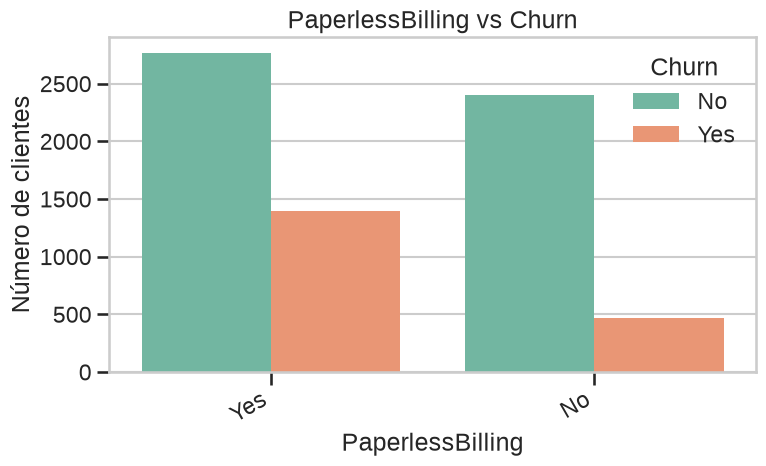


--- PaperlessBilling ---
Churn               No   Yes
PaperlessBilling            
No                83.7  16.3
Yes               66.4  33.6


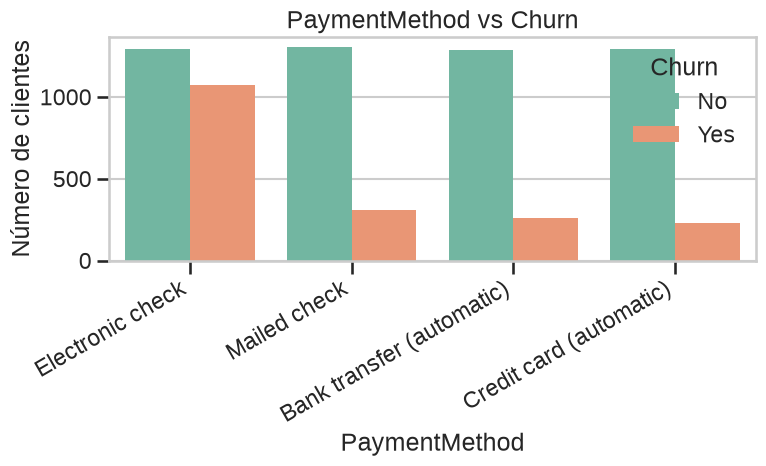


--- PaymentMethod ---
Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  83.3  16.7
Credit card (automatic)    84.8  15.2
Electronic check           54.7  45.3
Mailed check               80.9  19.1


In [39]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for col in cat_cols:
    if df[col].nunique() <= 10:
        fig, ax = plt.subplots(figsize=(8, 5))
        order = sorted(df[col].dropna().unique().tolist()) if pd.api.types.is_numeric_dtype(df[col]) else None
        sns.countplot(data=df, x=col, hue='Churn', order=order, palette='Set2', ax=ax)
        ax.set_title(f'{col} vs Churn')
        ax.set_xlabel(col)
        ax.set_ylabel('Número de clientes')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()
        print(f'\n--- {col} ---')
        print(pd.crosstab(df[col], df['Churn'], normalize='index').round(3) * 100)


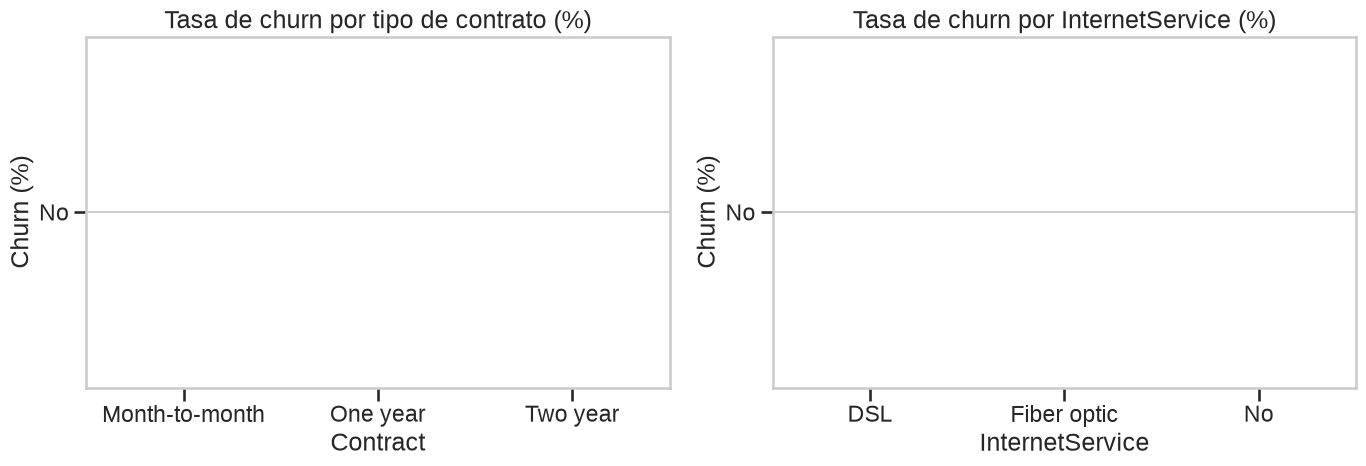

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Contract', y='Churn', estimator=lambda x: np.mean(x == 'Yes') * 100, ax=axes[0], palette='viridis')
axes[0].set_title('Tasa de churn por tipo de contrato (%)')
axes[0].set_xlabel('Contract')
axes[0].set_ylabel('Churn (%)')

sns.barplot(data=df, x='InternetService', y='Churn', estimator=lambda x: np.mean(x == 'Yes') * 100, ax=axes[1], palette='viridis')
axes[1].set_title('Tasa de churn por InternetService (%)')
axes[1].set_xlabel('InternetService')
axes[1].set_ylabel('Churn (%)')
plt.tight_layout()
plt.show()


## 7. Valores faltantes, outliers y problemas de calidad

Es fundamental detectar anomalías y valores no esperados antes de entrenar un modelo. Esto incluye valores faltantes, categorías raras y outliers que puedan distorsionar el análisis o introducir ruido.


Valores faltantes:
TotalCharges    11
dtype: int64


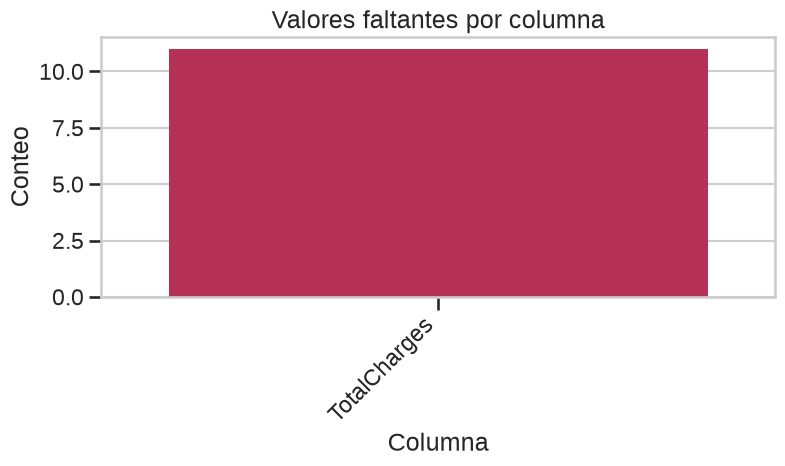

In [41]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('Valores faltantes:')
print(missing)

if not missing.empty:
    plt.figure(figsize=(8, 5))
    sns.barplot(x=missing.index, y=missing.values, palette='rocket')
    plt.title('Valores faltantes por columna')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Conteo')
    plt.xlabel('Columna')
    plt.tight_layout()
    plt.show()


In [42]:
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: {n_out} outliers potenciales (límites [{lower:.2f}, {upper:.2f}])')


tenure: 0 outliers potenciales (límites [-60.00, 124.00])
MonthlyCharges: 0 outliers potenciales (límites [-46.02, 171.38])
TotalCharges: 0 outliers potenciales (límites [-4688.48, 8884.67])


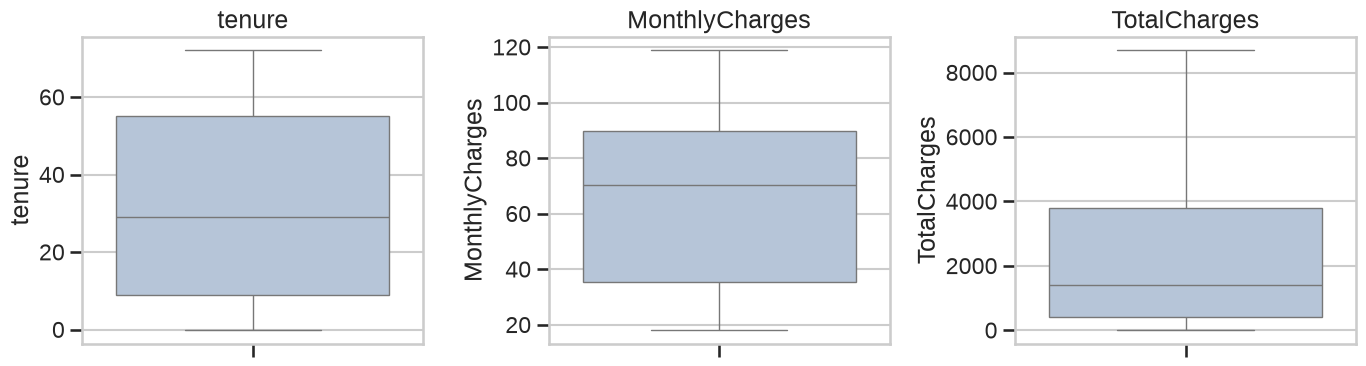

In [43]:
plt.figure(figsize=(14, 4))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges'], start=1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, y=col, color='lightsteelblue')
    plt.title(col)
plt.tight_layout()
plt.show()


## 8. Relaciones entre variables y posible data leakage

El análisis exploratorio no solo busca patrones de negocio, sino también detectar señales que podrían contaminar el modelo. En este dataset, aspectos como `customerID`, atributos derivados de la cuenta o variables que representen el estado actual del cliente deben revisarse con cuidado.

### Observaciones preliminares
- `customerID` es un identificador único: no aporta valor predictivo y debe excluirse del entrenamiento.
- `TotalCharges` parece estar relacionado con `MonthlyCharges` y `tenure`; puede ser una variable derivada, pero no necesariamente es leak si se usa como parte del comportamiento histórico del cliente.
- Las columnas de servicios adicionales (`OnlineSecurity`, `OnlineBackup`, etc.) están fuertemente relacionadas con el tipo de contrato y la categoría de internet; esto puede inducir multicolinealidad.
- Si se enfrentara un problema de predicción en un horizonte temporal específico, se debe asegurar que las variables no incorporen información del futuro no disponible al momento de la decisión.


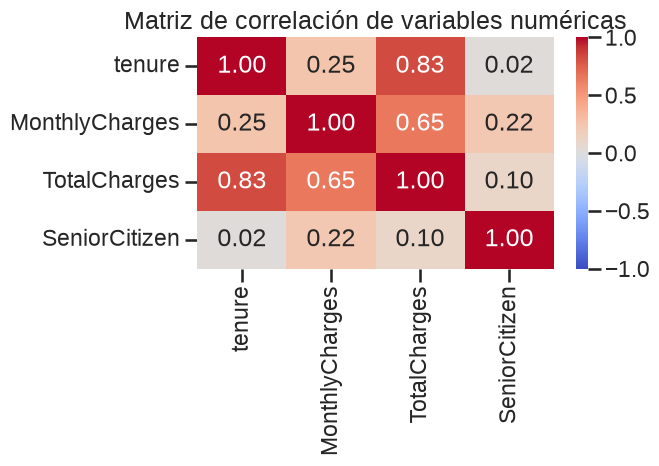

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
tenure,1.000000,0.247900,0.825880,0.016567
MonthlyCharges,0.247900,1.000000,0.651065,0.220173
TotalCharges,0.825880,0.651065,1.000000,0.102411
SeniorCitizen,0.016567,0.220173,0.102411,1.000000


In [44]:
num_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
correlation = num_df.corr(method='pearson')

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de correlación de variables numéricas')
plt.tight_layout()
plt.show()
correlation


## 9. Hallazgos clave del EDA

A partir del análisis exploratorio se observan varias señales importantes:

- La proporción de churn no es equilibrada, por lo que la métrica de evaluación debe ser sensible a desbalance.
- El tipo de contrato parece ser un indicador fuerte: clientes con contratos más largos tienden a abandonar menos.
- El servicio de internet y los add-ons pueden estar relacionados con la rotación de clientes.
- `TotalCharges` requiere limpieza y podría estar fuertemente ligado a la duración del servicio y al plan contratado.
- Hay variables categóricas con categorías semánticas como `No internet service`, que deben tratarse adecuadamente durante el preprocesamiento.
- Debe revisarse el uso de `customerID` y otras columnas identificadoras antes del modelado.


## 10. Propuesta de pasos siguientes

Para la siguiente etapa del proyecto, se propone:

1. Definir el conjunto de variables de entrada final, excluyendo identificadores y revisando posibles fuentes de leakage.
2. Realizar preprocesamiento: codificación de variables categóricas, manejo de valores faltantes y normalización cuando aplique.
3. Crear un baseline de referencia con un modelo simple.
4. Evaluar al menos dos modelos de clasificación (por ejemplo, Logistic Regression, Random Forest, XGBoost o Gradient Boosting).
5. Usar métricas apropiadas para problemas desbalanceados, como Recall, Precision, F1-score, ROC-AUC y/o PR-AUC.
6. Analizar e interpretar resultados con métricas, importancias de variables y curvas de desempeño.
